# EDA: Avito Demand Predictor

Цель проекта — разработать ML-сервис, который по характеристикам нового объявления (цена, категория, описание, изображения, информация о продавце и дата публикации) прогнозирует вероятность его высокой ликвидности.

Полученный прогноз может использоваться для:
- предоставления продавцам рекомендаций по продвижению объявления или корректировке цены;
- оптимизации ранжирования объявлений и монетизации платформы.

**Формат раздела:** анализ → визуализация → вывод.

---
# 1. Цель анализа & Бизнес-контекст

## 1.1 Бизнес-цель

Основная цель проекта — заранее оценивать ликвидность объявления, используя только информацию, доступную на момент его публикации.

Полученный прогноз может применяться для:

- **Продавца** — рекомендации по улучшению объявления, корректировке цены или использованию платного продвижения.
- **Платформы** — приоритизации объявлений в поисковой выдаче, персонализации рекомендаций и более эффективной монетизации сервисов продвижения.

> **Ключевое ограничение:** модель должна использовать только признаки, известные до публикации объявления. Любая информация, появляющаяся после публикации (просмотры, клики, сообщения пользователей, факт продажи и другие события), считается утечкой данных (**Data Leakage**) и не может использоваться при обучении модели.

**Вывод:** модель должна принимать решение исключительно на основе информации, доступной в момент создания объявления.

## 1.2 Постановка ML-задачи

В рамках проекта решается задача **бинарной классификации** — прогнозирования ликвидности нового объявления.

- **Тип задачи:** бинарная классификация (`ликвидное` / `неликвидное` объявление).
- **Целевая переменная:** исходные данные содержат непрерывную величину `deal_probability ∈ [0, 1]`, которая на этапе моделирования будет преобразована в бинарную целевую переменную.
- **Порог бинаризации:** не является свойством данных и рассматривается как отдельное проектное решение, принимаемое после анализа моделей.
- **Доступные признаки:** цена, категория, описание, изображения, регион, информация о продавце и дата публикации — то есть только данные, известные на момент публикации объявления.
- **Запрещённые признаки (Data Leakage):** просмотры, клики, сообщения пользователей, факт продажи и любые другие события, возникающие после публикации объявления.
- **Метрики качества:** основными метриками являются **ROC-AUC** и **PR-AUC**, поскольку они позволяют объективно оценивать качество ранжирования моделей при дисбалансе классов и не зависят от выбранного порога принятия решения.

**Вывод:** задача проекта — построить модель, способную по характеристикам нового объявления прогнозировать принадлежность объявления к классу ликвидных. Конкретный способ бинаризации целевой переменной определяется на этапе моделирования.

## 1.3 Основные гипотезы

* H1: цена влияет на вероятность быстрой продажи нелинейно.
* H2: категория важнее региона.
* H3: длинное описание повышает вероятность продажи.
* H4: компании продают быстрее частных продавцов.
* H5: пропуски в price/param_1-3 неслучайны.

---
# 2. Знакомство с данными

## 2.1 Загрузка данных

Читаем `train.csv` и `test.csv`.

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display


# Настройка корректной рабочей директории (если запуск из папки notebooks)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

# Настройки отображения pandas и seaborn
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

# Пути к данным
RAW_DATA_PATH = 'data/raw/'

# 1. Загрузка данных
train_df = pd.read_csv(f'{RAW_DATA_PATH}train.csv')
test_df = pd.read_csv(f'{RAW_DATA_PATH}test.csv')

# 2. Первичный срез структуры
train_df.head(3)

,item_id,user_id,region,city,parent_category_name,category_name,param_1,param_2,param_3,title,description,price,item_seq_number,activation_date,user_type,image,image_top_1,deal_probability
0,b912c3c6a6ad,e00f8ff2eaf9,Свердловская область,Екатеринбург,Личные вещи,Товары для детей и игрушки,Постельные принадлежности,NaN,NaN,Кокоби(кокон для сна),"Кокон для сна малыша,пользовались меньше месяц...",400.0,2,2017-03-28,Private,d10c7e016e03247a3bf2d13348fe959fe6f436c1caf64c...,1008.0,0.12789
1,2dac0150717d,39aeb48f0017,Самарская область,Самара,Для дома и дачи,Мебель и интерьер,Другое,NaN,NaN,Стойка для Одежды,"Стойка для одежды, под вешалки. С бутика.",3000.0,19,2017-03-26,Private,79c9392cc51a9c81c6eb91eceb8e552171db39d7142700...,692.0,0.00000
2,ba83aefab5dc,91e2f88dd6e3,Ростовская область,Ростов-на-Дону,Бытовая электроника,Аудио и видео,"Видео, DVD и Blu-ray плееры",NaN,NaN,Philips bluray,"В хорошем состоянии, домашний кинотеатр с blu ...",4000.0,9,2017-03-20,Private,b7f250ee3f39e1fedd77c141f273703f4a9be59db4b48a...,3032.0,0.43177


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503424 entries, 0 to 1503423
Data columns (total 18 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   item_id               1503424 non-null  object 
 1   user_id               1503424 non-null  object 
 2   region                1503424 non-null  object 
 3   city                  1503424 non-null  object 
 4   parent_category_name  1503424 non-null  object 
 5   category_name         1503424 non-null  object 
 6   param_1               1441848 non-null  object 
 7   param_2               848882 non-null   object 
 8   param_3               640859 non-null   object 
 9   title                 1503424 non-null  object 
 10  description           1387148 non-null  object 
 11  price                 1418062 non-null  float64
 12  item_seq_number       1503424 non-null  int64  
 13  activation_date       1503424 non-null  object 
 14  user_type             1503424 non-

**Вывод:** train — 1,503,424 строки × 18 столбцов, test — 508,438 строк × 17 столбцов. Разница в 1 столбец — это target `deal_probability`.

## 2.2 Размер данных

In [2]:
size_summary = pd.DataFrame({
    'Датасет': ['train', 'test'],
    'Строк': [train_df.shape[0], test_df.shape[0]],
    'Столбцов': [train_df.shape[1], test_df.shape[1]],
    'Память, MB': [
        round(train_df.memory_usage(deep=True).sum() / 1024**2, 1),
        round(test_df.memory_usage(deep=True).sum() / 1024**2, 1),
    ],
})
size_summary

,Датасет,Строк,Столбцов,"Память, MB"
0,train,1503424,18,2361.2
1,test,508438,17,808.2


**Вывод:** test ≈ 1/3 от train по числу строк. train занимает 2361.2 MB, test — 808.2 MB. Объем требует экономии памяти при выборе типов.

## 2.3 Описание признаков

In [3]:
# 2.3. Справочник признаков: смысл, тип, потенциальная полезность
feature_reference = pd.DataFrame([
    ('item_id',              'ID',        'Уникальный идентификатор объявления',                                   'Только ключ, в модель не идет'),
    ('user_id',               'ID',        'Идентификатор продавца',                                                'База для агрегатов по продавцу (частота публикаций и т.п.)'),
    ('region',                'Категориальный', 'Регион размещения',                                                'Локальный спрос/цены'),
    ('city',                  'Категориальный', 'Город размещения',                                                 'Высокая кардинальность, локальный спрос'),
    ('parent_category_name',  'Категориальный', 'Родительская категория товара',                                    'Сильный сигнал по гипотезе H2'),
    ('category_name',         'Категориальный', 'Категория товара',                                                 'Сильный сигнал по гипотезе H2'),
    ('param_1',                'Категориальный', 'Доп. параметр 1 (зависит от категории)',                           'Уточняет категорию, много пропусков'),
    ('param_2',                'Категориальный', 'Доп. параметр 2 (зависит от категории)',                           'Уточняет категорию, много пропусков'),
    ('param_3',                'Категориальный', 'Доп. параметр 3 (зависит от категории)',                           'Уточняет категорию, много пропусков'),
    ('title',                  'Текст',        'Заголовок объявления',                                              'Длина/качество текста — гипотеза H3'),
    ('description',            'Текст',        'Описание объявления',                                              'Длина/качество текста — гипотеза H3, NLP-признаки'),
    ('price',                  'Числовой',     'Цена товара',                                                       'Ключевой признак, гипотеза H1'),
    ('item_seq_number',        'Числовой',     'Порядковый номер объявления у данного пользователя',                'Прокси для типа продавца — гипотеза H4'),
    ('activation_date',        'Дата',         'Дата публикации объявления',                                       'День недели/сезонность, но не абсолютная дата (риск утечки во времени)'),
    ('user_type',              'Категориальный', 'Тип пользователя (Private/Company/Shop)',                          'Прямой признак для гипотезы H4'),
    ('image',                  'ID/файл',      'Идентификатор фото объявления',                                     'Наличие фото — гипотеза H3, признак has_image'),
    ('image_top_1',            'Числовой/категориальный', 'Код класса изображения (из внутреннего классификатора Avito)', 'Прокси-признак по содержимому фото'),
    ('deal_probability',       'Target',       'Вероятность сделки (только в train)',                              'Целевая переменная'),
], columns=['Признак', 'Тип', 'Смысл', 'Потенциальная полезность'])

feature_reference

,Признак,Тип,Смысл,Потенциальная полезность
0,item_id,ID,Уникальный идентификатор объявления,"Только ключ, в модель не идет"
1,user_id,ID,Идентификатор продавца,База для агрегатов по продавцу (частота публик...
2,region,Категориальный,Регион размещения,Локальный спрос/цены
3,city,Категориальный,Город размещения,"Высокая кардинальность, локальный спрос"
4,parent_category_name,Категориальный,Родительская категория товара,Сильный сигнал по гипотезе H2
5,category_name,Категориальный,Категория товара,Сильный сигнал по гипотезе H2
6,param_1,Категориальный,Доп. параметр 1 (зависит от категории),"Уточняет категорию, много пропусков"
7,param_2,Категориальный,Доп. параметр 2 (зависит от категории),"Уточняет категорию, много пропусков"
8,param_3,Категориальный,Доп. параметр 3 (зависит от категории),"Уточняет категорию, много пропусков"
9,title,Текст,Заголовок объявления,Длина/качество текста — гипотеза H3


**Вывод:** все 17 признаков train/test укладываются в список разрешенных. `deal_probability` — единственный target, из него получим бинарный label.

## 2.4 Типы данных

Проверяем структуру и типы признаков — чтобы каждый признак интерпретировался корректно и данные были готовы к Feature Engineering. Смотрим: dtype, пропуски, число уникальных значений и логическую группу (id / числовой / категориальный / текстовый / дата / target).

In [4]:
# Анализ типов данных и структуры колонок

def inspect_columns(df):
    summary = pd.DataFrame({
        'Dtype': df.dtypes,
        'Non-Null Count': df.notnull().sum(),
        'Null Count': df.isnull().sum(),
        'Null %': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique Values': df.nunique(dropna=True),
        'Sample Value': df.iloc[0]
    })
    return summary

# Вызываем просмотр структуры train_df
train_structure = inspect_columns(train_df)
train_structure

,Dtype,Non-Null Count,Null Count,Null %,Unique Values,Sample Value
item_id,object,1503424,0,0.00,1503424,b912c3c6a6ad
user_id,object,1503424,0,0.00,771769,e00f8ff2eaf9
region,object,1503424,0,0.00,28,Свердловская область
city,object,1503424,0,0.00,1733,Екатеринбург
parent_category_name,object,1503424,0,0.00,9,Личные вещи
category_name,object,1503424,0,0.00,47,Товары для детей и игрушки
param_1,object,1441848,61576,4.10,371,Постельные принадлежности
param_2,object,848882,654542,43.54,271,NaN
param_3,object,640859,862565,57.37,1219,NaN
title,object,1503424,0,0.00,788377,Кокоби(кокон для сна)


In [5]:
# Группировка признаков по типам для последующего анализа

# Идентификаторы
id_cols = ['item_id', 'user_id', 'image']

# Временной признак
date_cols = ['activation_date']

# Целевая переменная
target_col = 'deal_probability'

# Числовые признаки
num_cols = ['price', 'item_seq_number']

# Категориальные признаки
cat_cols = [
    'region', 'city', 'parent_category_name', 'category_name', 
    'param_1', 'param_2', 'param_3', 'user_type', 'image_top_1'
]

# Текстовые признаки
text_cols = ['title', 'description']

print(f"Идентификаторы: {len(id_cols)}")
print(f"Числовые признаки: {len(num_cols)}")
print(f"Категориальные признаки: {len(cat_cols)}")
print(f"Текстовые признаки: {len(text_cols)}")
print(f"Временные признаки: {len(date_cols)}")

Идентификаторы: 3
Числовые признаки: 2
Категориальные признаки: 9
Текстовые признаки: 2
Временные признаки: 1


**Вывод:** структура соответствует постановке задачи.
* **ID** (`item_id`, `user_id`, `image`) — не участвуют в обучении, только идентификация.
* **Числовые** (`price`, `item_seq_number`) — нужен отдельный анализ распределений и выбросов.
* **Категориальные** (регион, категория, характеристики) — основной источник предиктивного сигнала.
* **Текстовые** (`title`, `description`) — источник для новых признаков.
* **`activation_date`** — база для сезонности и календарных признаков.

Признаки приводятся к подходящим типам — это снижает память и убирает лишние преобразования для ML-библиотек.

In [6]:
train_df['activation_date'] = pd.to_datetime(train_df['activation_date'])
test_df['activation_date'] = pd.to_datetime(test_df['activation_date'])

for col in cat_cols:
    train_df[col] = train_df[col].astype('category')
    test_df[col] = test_df[col].astype('category')

train_df['image_top_1'] = train_df['image_top_1'].astype('Int64')
test_df['image_top_1'] = test_df['image_top_1'].astype('Int64')

train_df[date_cols + cat_cols + ['image_top_1']].dtypes

activation_date         datetime64[ns]
region                        category
city                          category
parent_category_name          category
category_name                 category
param_1                       category
param_2                       category
param_3                       category
user_type                     category
image_top_1                      Int64
image_top_1                      Int64
dtype: object

In [7]:
train_memory_after = round(train_df.memory_usage(deep=True).sum() / 1024**2, 1)
test_memory_after = round(test_df.memory_usage(deep=True).sum() / 1024**2, 1)

print(f"Память после оптимизации — train: {train_memory_after} MB, test: {test_memory_after} MB")


Память после оптимизации — train: 1292.5 MB, test: 432.3 MB


**Вывод:**
* `activation_date` → `datetime` — можно извлекать календарные признаки.
* Категориальные признаки → `category`, `image_top_1` → `Int64` (сохраняет пропуски).
* После оптимизации train занимает 1292.5 MB, test — 432.3 MB. Схема типов зафиксирована и используется одинаково при обучении и на инференсе.

---
# 3. Анализ качества данных

## 3.1 Пропущенные значения

In [8]:
# Сравнительный анализ пропусков в train и test

def get_missing_report(train, test):
    train_missing = train.isnull().sum()
    test_missing = test.isnull().sum()
    
    report = pd.DataFrame({
        'Train Missing': train_missing,
        'Train %': (train_missing / len(train) * 100).round(2),
        'Test Missing': test_missing,
        'Test %': (test_missing / len(test) * 100).round(2),
        'Dtype': train.dtypes
    })
    
    # Фильтруем только признаки, имеющие хотя бы 1 пропуск в одной из выборок
    report = report[(report['Train Missing'] > 0) | (report['Test Missing'] > 0)]
    return report.sort_values(by='Train %', ascending=False)

missing_report = get_missing_report(train_df, test_df)
missing_report

,Train Missing,Train %,Test Missing,Test %,Dtype
param_3,862565,57.37,306331.0,60.25,category
param_2,654542,43.54,233229.0,45.87,category
description,116276,7.73,0.0,0.00,object
image_top_1,112588,7.49,42609.0,8.38,Int64
image,112588,7.49,42609.0,8.38,object
price,85362,5.68,30585.0,6.02,float64
param_1,61576,4.10,22910.0,4.51,category


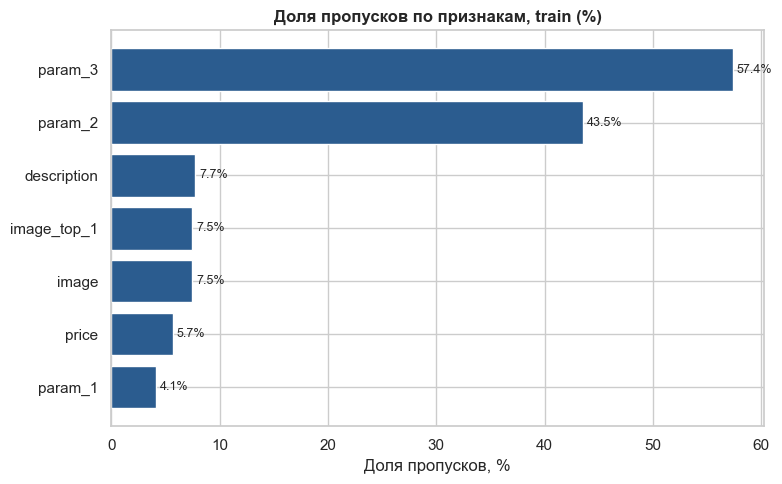

In [9]:
missing_share = (train_df.isnull().mean() * 100).round(2)
missing_share = missing_share[missing_share > 0].sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(missing_share.index, missing_share.values, color='#2b5c8f')
ax.set_title('Доля пропусков по признакам, train (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Доля пропусков, %')
for b in bars:
    ax.annotate(f'{b.get_width():.1f}%', (b.get_width(), b.get_y() + b.get_height()/2),
                va='center', ha='left', fontsize=9, xytext=(3, 0), textcoords='offset points')
plt.tight_layout()
plt.show()

**Вывод:**
* `param_3` (57%) и `param_2` (44%) — пропуски из-за специфики категории (не у всех товаров есть 2-й/3-й параметр) → заполнять `'Missing'`.
* `image`/`image_top_1` (7.5%) — отсутствие фото → отдельный флаг `has_image`.
* `price` (5.7%) — договорная цена → импутация медианой по категории + флаг `price_is_missing`.
* Доли пропусков в train и test совпадают — пропуски системные, не случайные (гипотеза H5 подтверждается).

## 3.2 Дубликаты

In [10]:
# Анализ дубликатов (Full Duplicates & Identifier Checks)

# 1. Проверка полных дубликатов
full_duplicates_train = train_df.duplicated().sum()
full_duplicates_test = test_df.duplicated().sum()

# 2. Проверка уникальности первичного ключа (item_id)
item_id_unique_train = train_df['item_id'].nunique() == len(train_df)
item_id_unique_test = test_df['item_id'].nunique() == len(test_df)

# 3. Поиск повторяющихся объявлений (один и тот же пользователь, заголовок и цена)
content_duplicates_train = train_df.duplicated(subset=['user_id', 'title', 'price']).sum()

print(f"Полных дубликатов в Train: {full_duplicates_train}")
print(f"Полных дубликатов в Test:  {full_duplicates_test}")
print(f"Все item_id уникальны в Train: {item_id_unique_train}")
print(f"Все item_id уникальны в Test:  {item_id_unique_test}")
print(f"Дубликатов по содержанию (user_id + title + price) в Train: {content_duplicates_train} ({content_duplicates_train / len(train_df) * 100:.2f}%)")

Полных дубликатов в Train: 0
Полных дубликатов в Test:  0
Все item_id уникальны в Train: True
Все item_id уникальны в Test:  True
Дубликатов по содержанию (user_id + title + price) в Train: 21011 (1.40%)


**Вывод:** полных дубликатов строк нет, `item_id` уникален у всех объявлений. 21,011 объявлений (1.4%) — повтор публикации (тот же пользователь + заголовок + цена). Удалять нечего, повтор публикации — кандидат в отдельный признак.

## 3.3 Некорректные значения

In [11]:
checks = {
    'price < 0 (train)': (train_df['price'] < 0).sum(),
    'price == 0 (train)': (train_df['price'] == 0).sum(),
    'title пустой (train)': (train_df['title'].fillna('').str.strip() == '').sum(),
    'description пустой (train)': (train_df['description'].fillna('').str.strip() == '').sum(),
    'item_seq_number <= 0 (train)': (train_df['item_seq_number'] <= 0).sum(),
    'deal_probability вне [0,1] (train)': (~train_df['deal_probability'].between(0, 1)).sum(),
}
pd.Series(checks, name='Результат')

price < 0 (train)                          0
price == 0 (train)                      4646
title пустой (train)                       0
description пустой (train)            116276
item_seq_number <= 0 (train)               0
deal_probability вне [0,1] (train)         0
Name: Результат, dtype: int64

**Вывод:**
* Отрицательных цен нет.
* `price == 0` — 4,646 объявлений (0.3%), это легитимная категория «отдам даром», не ошибка.
* Пустых заголовков нет, но 116,276 объявлений (7.7%) — без описания (совпадает с пропусками `description` из 3.1).
* `item_seq_number` и `deal_probability` — без аномалий, значения в ожидаемых границах.

## 3.4 Выбросы

,p1,p5,p50,p95,p99,p99.9
price,17.0,100.0,"1,300.0","1,380,000.0","4,050,000.0","19,000,000.0"
item_seq_number,1.0,1.0,29.0,"1,255.0","19,790.3","76,681.6"


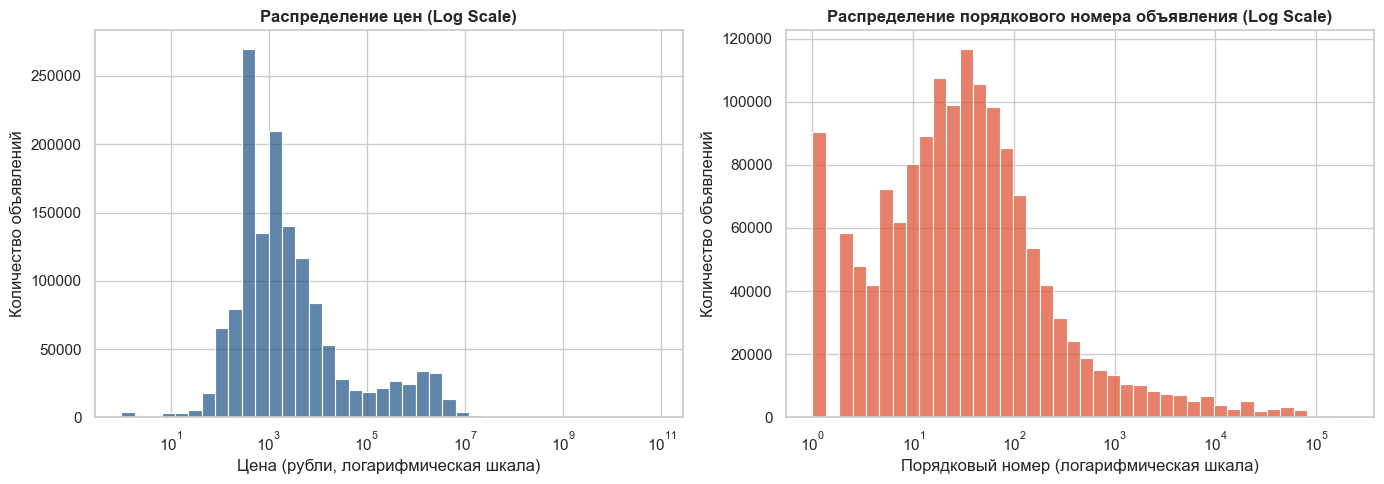

In [12]:
# Визуализация распределения числовых признаков 

# 1. Красивая таблица квантилей
quantiles = train_df[['price', 'item_seq_number']].quantile([0.01, 0.05, 0.50, 0.95, 0.99, 0.999]).T
quantiles.columns = ['p1', 'p5', 'p50', 'p95', 'p99', 'p99.9']

display(quantiles.style.format('{:,.1f}').set_caption("Квантили числовых признаков"))

# Добавляем небольшой отступ (1-2 пустые строки)
display(HTML('<div style="height: 20px;"></div>'))

# 2. Построение понятных графиков
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение цен (Log scale)
sns.histplot(
    data=train_df, x='price', log_scale=True, bins=40, ax=axes[0], color='#2b5c8f'
)
axes[0].set_title('Распределение цен (Log Scale)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Цена (рубли, логарифмическая шкала)')
axes[0].set_ylabel('Количество объявлений')

# Распределение номеров объявлений (Log scale)
sns.histplot(
    data=train_df, x='item_seq_number', log_scale=True, bins=40, ax=axes[1], color='#e05638'
)
axes[1].set_title('Распределение порядкового номера объявления (Log Scale)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Порядковый номер (логарифмическая шкала)')
axes[1].set_ylabel('Количество объявлений')

plt.tight_layout()
plt.show()

C:\Users\Omen\AppData\Local\Temp\ipykernel_20980\505005820.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = train_df.groupby('parent_category_name')['price'].median().sort_values(ascending=False).index


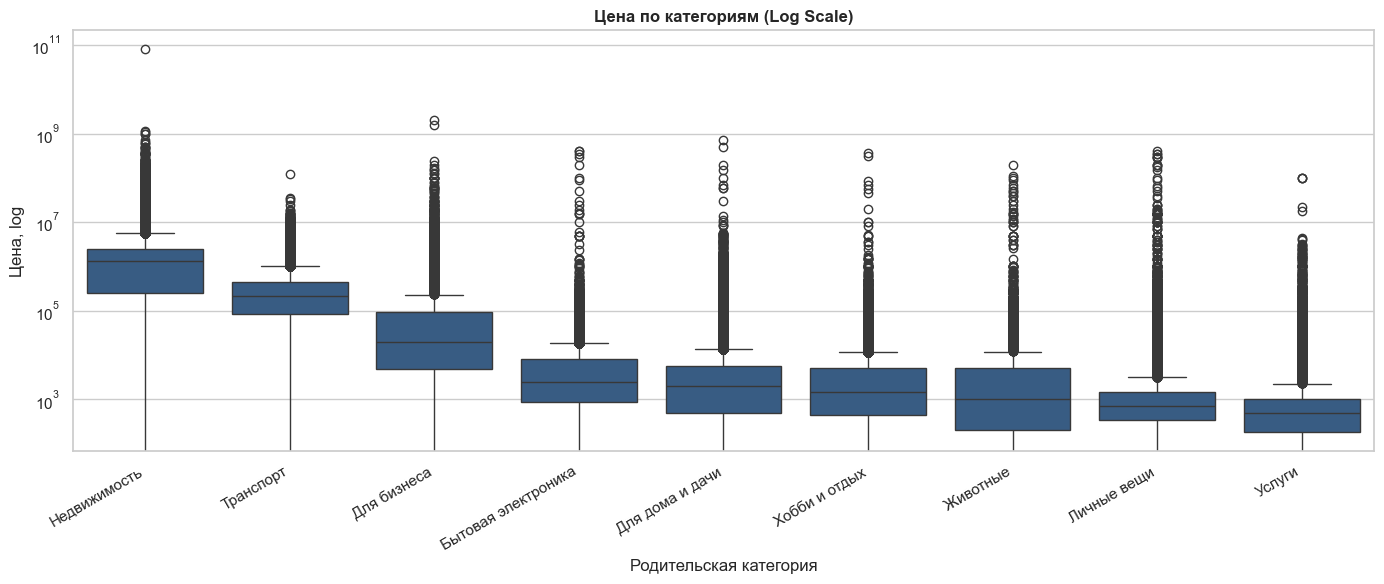

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
order = train_df.groupby('parent_category_name')['price'].median().sort_values(ascending=False).index

sns.boxplot(data=train_df, x='parent_category_name', y='price', order=order, ax=ax, color='#2b5c8f')
ax.set_yscale('log')
ax.set_title('Цена по категориям (Log Scale)', fontsize=12, fontweight='bold')
ax.set_xlabel('Родительская категория')
ax.set_ylabel('Цена, log')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Вывод:**
* Медиана цены — 1,300 руб., p99 — 4.05 млн руб., p99.9 — 19 млн руб.: сильно правый хвост.
* На boxplot по категориям видно, что дорогие товары сосредоточены в «Транспорте» и «Недвижимости» — это реальные цены, а не выбросы; искать аномалии нужно внутри категории, а не по общему порогу.
* `item_seq_number`: медиана 29, но p99.9 — 76,682 — резкий отрыв говорит о высокоактивных продавцах (бизнес/боты) на фоне обычных частных объявлений.

## 3.5 Кардинальность категорий

In [14]:
cardinality_rows = []
for col in cat_cols:
    vc = train_df[col].value_counts(dropna=False)
    cardinality_rows.append({
        'Признак': col,
        'Уникальных значений': train_df[col].nunique(dropna=True),
        'Топ-категория': vc.index[0],
        'Доля топ-категории, %': round(vc.iloc[0] / len(train_df) * 100, 2),
        'Редких категорий (<0.1%)': (vc / len(train_df) < 0.001).sum(),
    })

pd.DataFrame(cardinality_rows).sort_values('Уникальных значений', ascending=False)

,Признак,Уникальных значений,Топ-категория,"Доля топ-категории, %",Редких категорий (<0.1%)
8,image_top_1,3062,<NA>,7.49,2873
1,city,1733,Краснодар,4.23,1623
6,param_3,1219,NaN,57.37,1154
4,param_1,371,Женская одежда,15.05,258
5,param_2,271,NaN,43.54,202
3,category_name,47,"Одежда, обувь, аксессуары",18.81,1
0,region,28,Краснодарский край,9.41,0
2,parent_category_name,9,Личные вещи,46.40,0
7,user_type,3,Private,71.55,0


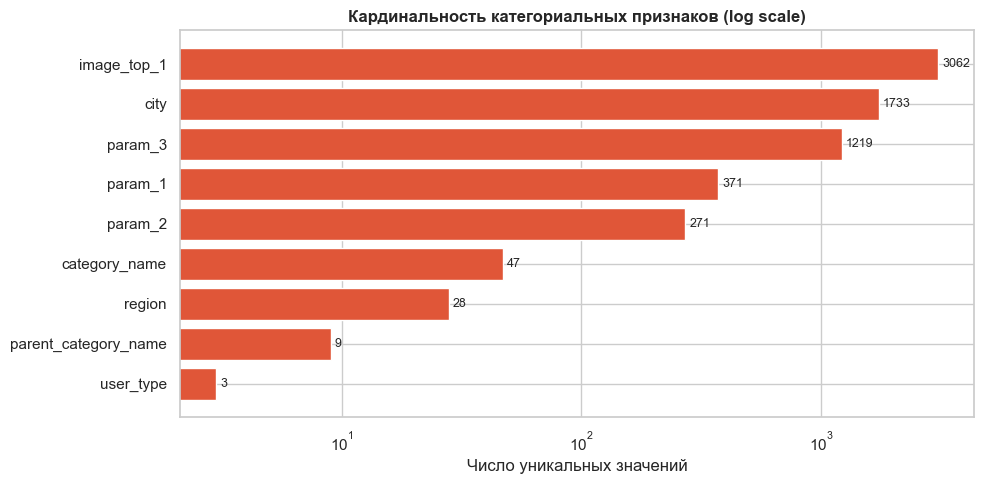

In [15]:
cardinality_counts = train_df[cat_cols].nunique().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(cardinality_counts.index, cardinality_counts.values, color='#e05638')
ax.set_xscale('log')
ax.set_title('Кардинальность категориальных признаков (log scale)', fontsize=12, fontweight='bold')
ax.set_xlabel('Число уникальных значений')
for i, v in enumerate(cardinality_counts.values):
    ax.annotate(f'{v}', (v, i), va='center', ha='left', fontsize=9, xytext=(3, 0), textcoords='offset points')
plt.tight_layout()
plt.show()

**Вывод:**
* Высокая кардинальность: `city` (1,733), `param_3` (1,219), `param_1` (371), `param_2` (271) → нужны target/frequency encoding, а не One-Hot.
* У `param_2`/`param_3` "топ-категория" по факту — это пропуск (NaN), а не реальное значение — совпадает с 3.1.
* Низкая кардинальность: `parent_category_name` (9), `region` (28), `user_type` (3) → подходит One-Hot.
* `category_name` (47 значений) почти без длинного хвоста (всего 1 редкая категория) — можно кодировать напрямую.

---
# 4. Анализ целевой переменной

## 4.1 Распределение target

C:\Users\Omen\AppData\Local\Temp\ipykernel_20980\1275042282.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prob_types, x='Тип значения', y='Доля, %', palette='Blues_r', ax=axes[1])


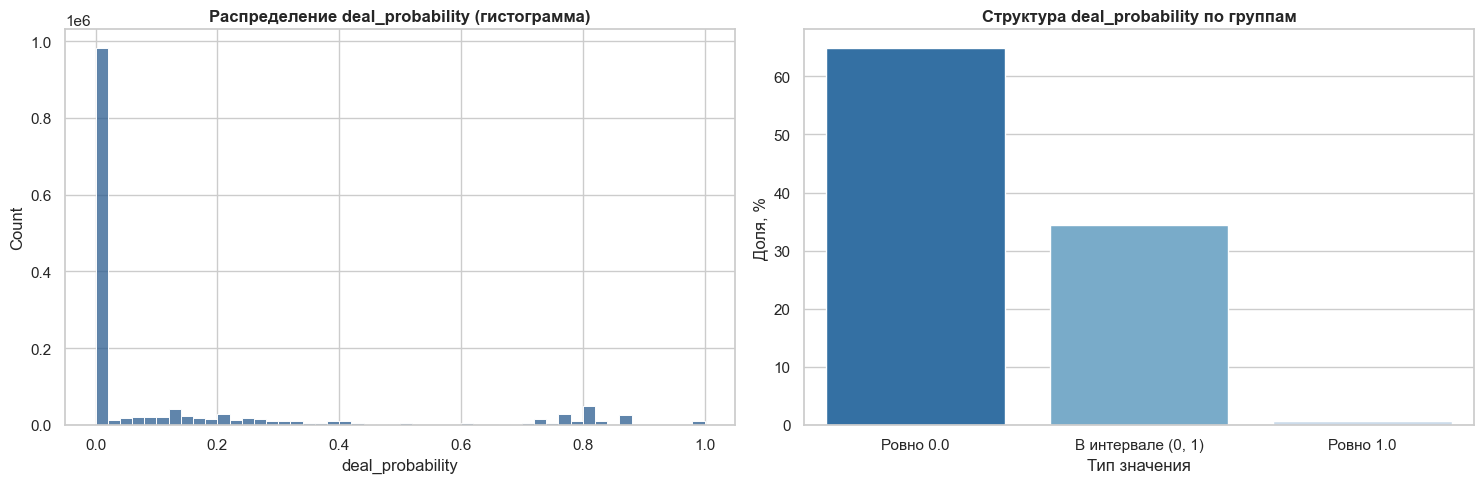

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма распределения deal_probability
sns.histplot(data=train_df, x=target_col, bins=50, color='#2b5c8f', ax=axes[0])
axes[0].set_title('Распределение deal_probability (гистограмма)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('deal_probability')

# Группировка по типу значений
zero_count = (train_df[target_col] == 0).sum()
exact_one_count = (train_df[target_col] == 1).sum()
in_between_count = ((train_df[target_col] > 0) & (train_df[target_col] < 1)).sum()

prob_types = pd.DataFrame({
    'Тип значения': ['Ровно 0.0', 'В интервале (0, 1)', 'Ровно 1.0'],
    'Доля, %': [
        round(zero_count / len(train_df) * 100, 2),
        round(in_between_count / len(train_df) * 100, 2),
        round(exact_one_count / len(train_df) * 100, 2)
    ]
})

sns.barplot(data=prob_types, x='Тип значения', y='Доля, %', palette='Blues_r', ax=axes[1])
axes[1].set_title('Структура deal_probability по группам', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [17]:
prob_types

,Тип значения,"Доля, %"
0,Ровно 0.0,64.83
1,"В интервале (0, 1)",34.50
2,Ровно 1.0,0.67


**Вывод:**
* 64.83% объявлений имеют `deal_probability == 0.0` — сделки не было.
* 34.50% — в промежуточном диапазоне (0, 1).
* 0.67% — `deal_probability == 1.0`, гарантированная продажа (редкий случай, не 9%, как казалось по графику).
* Распределение "zero-inflated": пик в нуле + тонкий хвост к 1 — обычная регрессия здесь неудобна, отсюда решение о бинаризации.

## 4.2 Баланс при разных порогах (диагностика, не выбор)

Целевая переменная `deal_probability` непрерывна. Бинаризация — отдельное проектное решение (см. 1.2), а не свойство данных, поэтому порог здесь **не фиксируется**.

Ниже — только диагностика: как меняется баланс классов в зависимости от кандидата на порог. Сам выбор порога — в разделе 10 (Modeling), где его можно сравнить по ROC-AUC/PR-AUC/Precision/Recall на предсказаниях baseline-модели, а не вслепую по одной лишь доле класса.

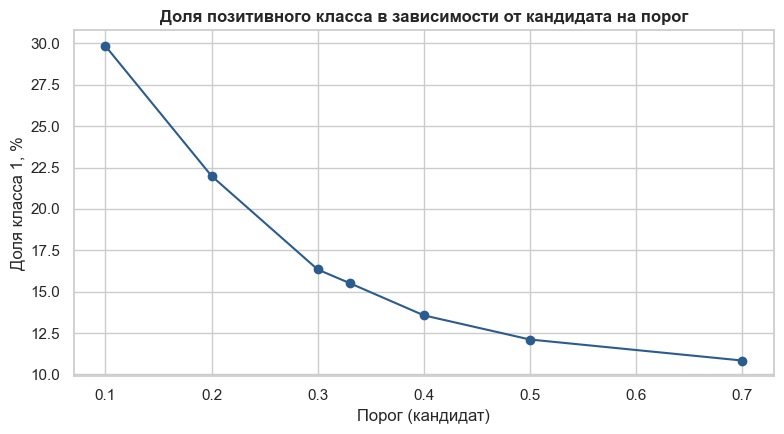

,threshold,"Доля класса 1, %"
0,0.10,29.84
1,0.20,21.99
2,0.30,16.34
3,0.33,15.52
4,0.40,13.57
5,0.50,12.11
6,0.70,10.84


In [18]:
thresholds = [0.1, 0.2, 0.3, 0.33, 0.4, 0.5, 0.7]
sweep_rows = []
for th in thresholds:
    pos_share = (train_df[target_col] >= th).mean() * 100
    sweep_rows.append({'threshold': th, 'Доля класса 1, %': round(pos_share, 2)})

sweep_df = pd.DataFrame(sweep_rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sweep_df['threshold'], sweep_df['Доля класса 1, %'], marker='o', color='#2b5c8f')
ax.set_title('Доля позитивного класса в зависимости от кандидата на порог', fontsize=12, fontweight='bold')
ax.set_xlabel('Порог (кандидат)')
ax.set_ylabel('Доля класса 1, %')
plt.tight_layout()
plt.show()

sweep_df

Для дальнейших иллюстративных разрезов в этом ноутбуке (не для финального пайплайна) используется рабочий ориентир `deal_probability ≥ 0.33`. Выбор носит эвристический характер и дает умеренно несбалансированную выборку. Он не финальный — чувствительность к порогу проверяется на этапе Modeling.

In [19]:
WORKING_THRESHOLD = 0.33  # рабочий ориентир для EDA-иллюстраций, не финальное решение
pos_share = (train_df[target_col] >= WORKING_THRESHOLD).mean() * 100

print(f"Рабочий ориентир: {WORKING_THRESHOLD}")
print(f"Доля класса 1: {pos_share:.2f}%")

Рабочий ориентир: 0.33
Доля класса 1: 15.52%


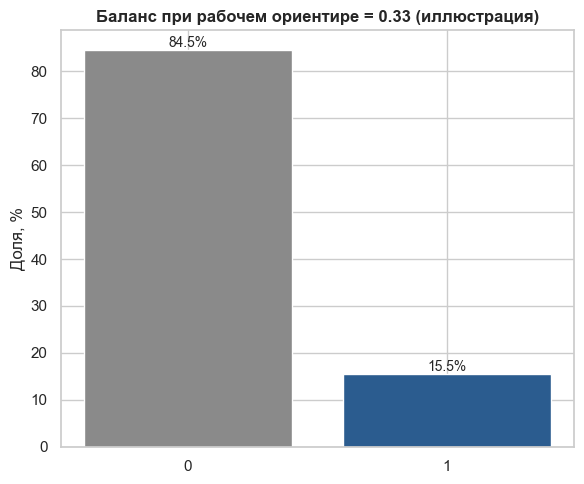

In [20]:
balance = pd.Series({
    '0': 100 - pos_share,
    '1': pos_share,
})

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(balance.index, balance.values, color=['#8a8a8a', '#2b5c8f'])
ax.set_title(f'Баланс при рабочем ориентире = {WORKING_THRESHOLD} (иллюстрация)', fontsize=12, fontweight='bold')
ax.set_ylabel('Доля, %')
for b in bars:
    ax.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width()/2, b.get_height()), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

**Вывод:** при ориентире 0.33 получаем 84.5% / 15.5% — рабочий диапазон для иллюстрации, не более. Финальный порог и его чувствительность (как меняются ROC-AUC/PR-AUC/Precision/Recall при 0.2/0.3/0.4/0.5) — предмет раздела 10, после того как появится baseline-модель.

## 4.3 Выбор метрик

Метрики планируем под задачу ранжирования/классификации, независимо от точного порога:
* **RMSE** — метрика для регрессии на непрерывном `deal_probability`, справочная: не отвечает на бизнес-вопрос напрямую (не про ранжирование/классификацию).
* **ROC-AUC** — не зависит от выбора порога, оценивает общее качество ранжирования по вероятности — можно использовать уже сейчас, до финального решения по порогу.
* **PR-AUC** — тоже не завязана на конкретный порог, но чувствительнее к качеству на позитивном классе, что важно при дисбалансе.

**Вывод:** ROC-AUC и PR-AUC — основные метрики; они же используются в разделе 10 для сравнения кандидатов на порог.

---
# 5. Проверка продуктовых гипотез

## 5.1 Цена и активность продавца (price, item_seq_number)

Проверяем гипотезу H1: цена влияет на вероятность продажи нелинейно.

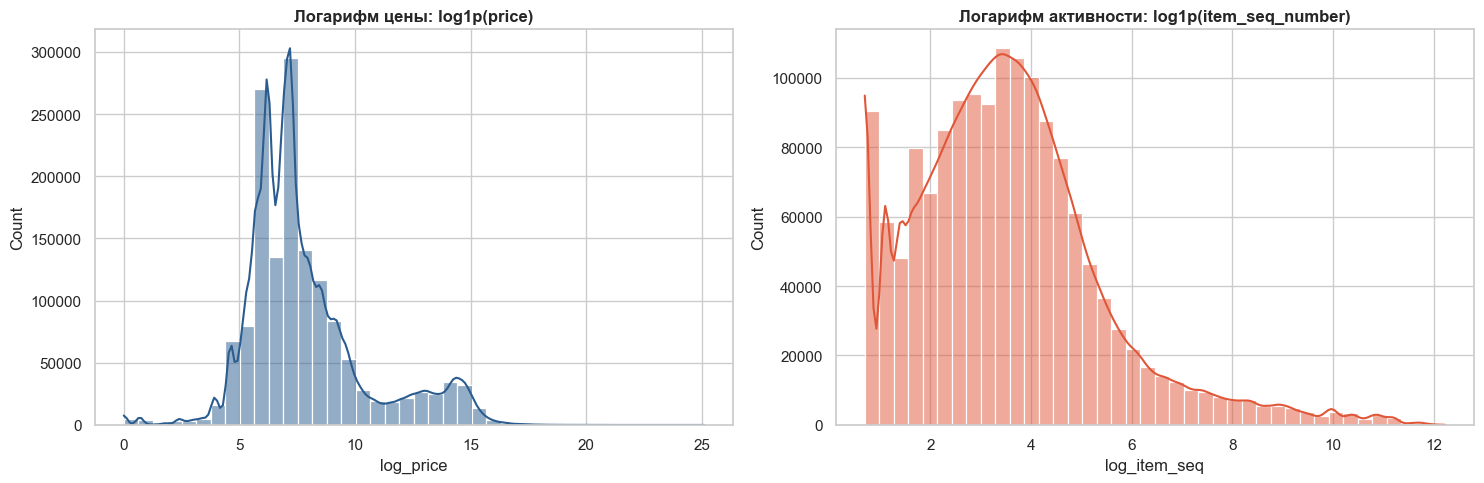

In [21]:
train_df['log_price'] = np.log1p(train_df['price'].fillna(train_df['price'].median()))
train_df['log_item_seq'] = np.log1p(train_df['item_seq_number'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=train_df, x='log_price', bins=40, kde=True, ax=axes[0], color='#2b5c8f')
axes[0].set_title('Логарифм цены: log1p(price)', fontsize=12, fontweight='bold')

sns.histplot(data=train_df, x='log_item_seq', bins=40, kde=True, ax=axes[1], color='#e05638')
axes[1].set_title('Логарифм активности: log1p(item_seq_number)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


**Вывод:** `log1p(price)` бимодален — дешевый бытовой C2C-сегмент (пик около 0) и дорогой сегмент авто/недвижимости (второй пик правее). `log1p(item_seq_number)` тоже смещен вправо — основная масса продавцов имеет мало объявлений, длинный хвост высокоактивных.

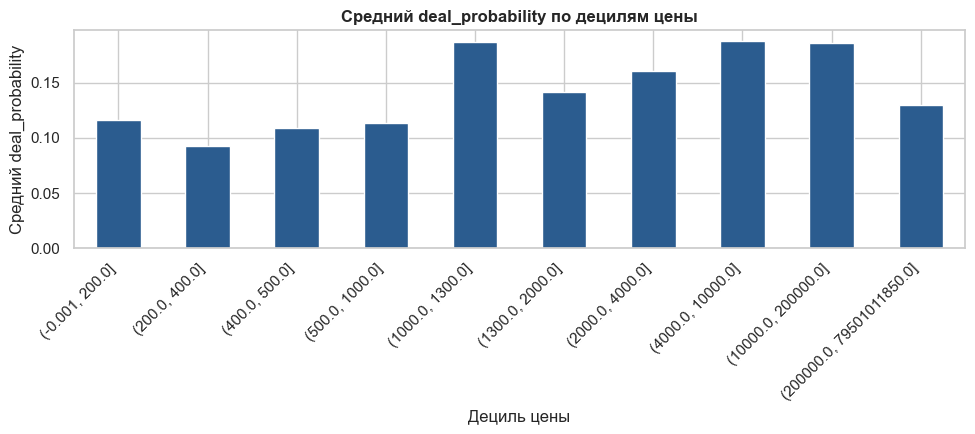

In [22]:
price_bins = pd.qcut(train_df['price'].fillna(train_df['price'].median()), q=10, duplicates='drop')
price_vs_target = train_df.groupby(price_bins, observed=True)['deal_probability'].mean()

fig, ax = plt.subplots(figsize=(10, 4.5))
price_vs_target.plot(kind='bar', ax=ax, color='#2b5c8f')
ax.set_title('Средний deal_probability по децилям цены', fontsize=12, fontweight='bold')
ax.set_xlabel('Дециль цены')
ax.set_ylabel('Средний deal_probability')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Вывод:** зависимость нелинейна и немонотонна — самые дешевые товары (децили 1-4) дают средний `deal_probability` ≈0.09-0.11, а самые дорогие (дециль 10) — только ≈0.13. Максимум (≈0.18-0.19) — у дециля 8-9, это не крайние, а средне-высокие цены. **H1 подтверждена**: связь есть, и она не «чем дешевле/дороже, тем лучше», а колоколообразная.

## 5.2 Категория и регион

Проверяем гипотезу H2: категория важнее региона.

C:\Users\Omen\AppData\Local\Temp\ipykernel_20980\3190096112.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_parent.values, y=top_parent.index, palette='Blues_r', ax=axes[0])
C:\Users\Omen\AppData\Local\Temp\ipykernel_20980\3190096112.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_reg.values, y=top_reg.index, palette='Oranges_r', ax=axes[1])


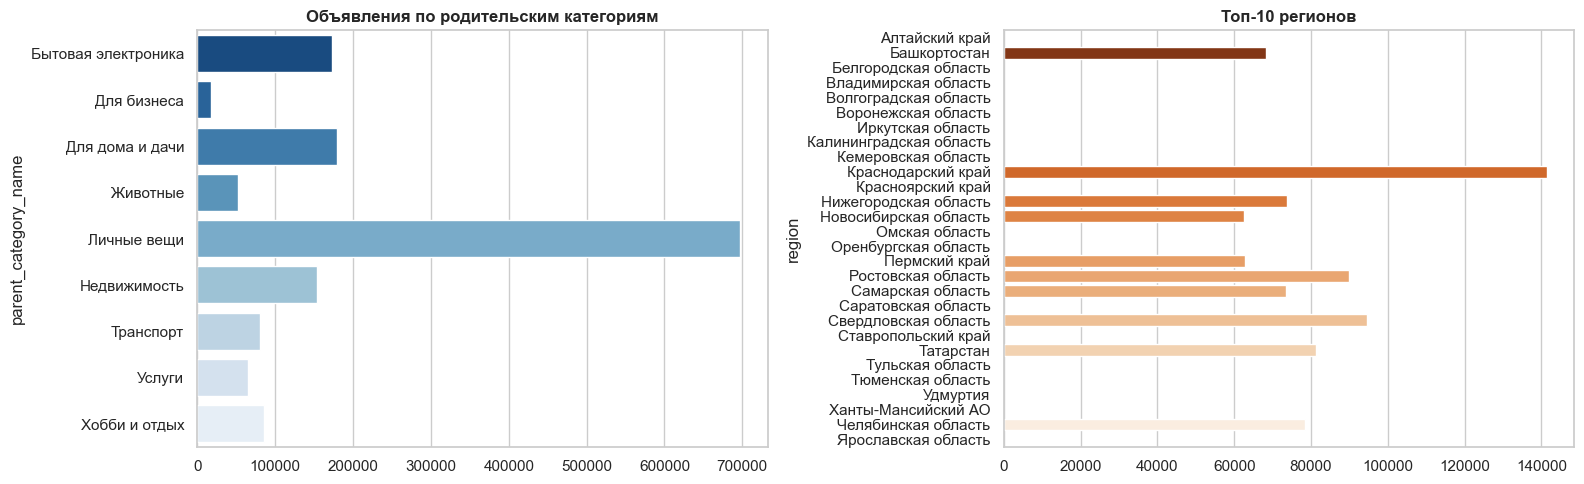

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_parent = train_df['parent_category_name'].value_counts()
sns.barplot(x=top_parent.values, y=top_parent.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Объявления по родительским категориям', fontsize=12, fontweight='bold')

top_reg = train_df['region'].value_counts().head(10)
sns.barplot(x=top_reg.values, y=top_reg.index, palette='Oranges_r', ax=axes[1])
axes[1].set_title('Топ-10 регионов', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


**Вывод:** «Личные вещи» — самая частая родительская категория (совпадает с топ-долей 46.4% из 3.5). По регионам явного одного лидера с большим отрывом нет — распределение объявлений по регионам более равномерное.

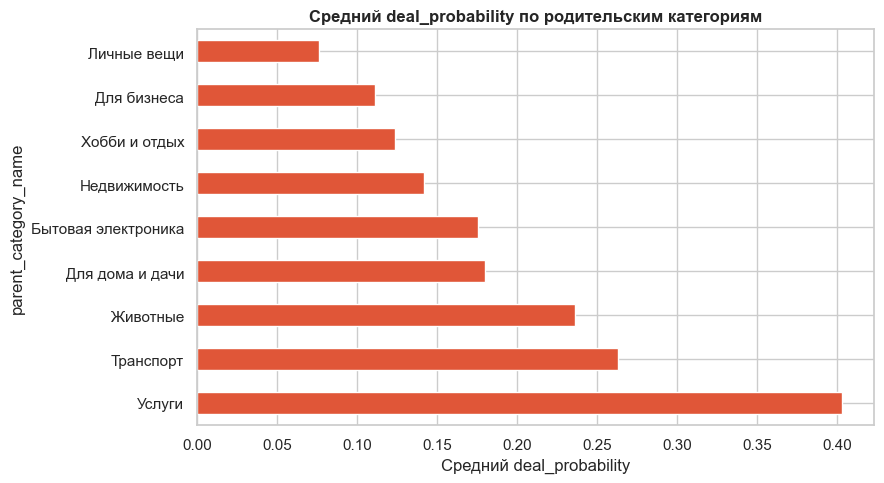

In [24]:
category_vs_target = train_df.groupby('parent_category_name', observed=True)['deal_probability'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
category_vs_target.plot(kind='barh', ax=ax, color='#e05638')
ax.set_title('Средний deal_probability по родительским категориям', fontsize=12, fontweight='bold')
ax.set_xlabel('Средний deal_probability')
plt.tight_layout()
plt.show()

**Вывод:** средний `deal_probability` по категориям различается в 5+ раз — от ≈0.08 («Личные вещи», самая частая категория) до ≈0.40 («Услуги»). «Транспорт» и «Животные» тоже заметно выше среднего (≈0.26 и ≈0.23). Категория явно сильно влияет на target — сравним с регионом ниже.

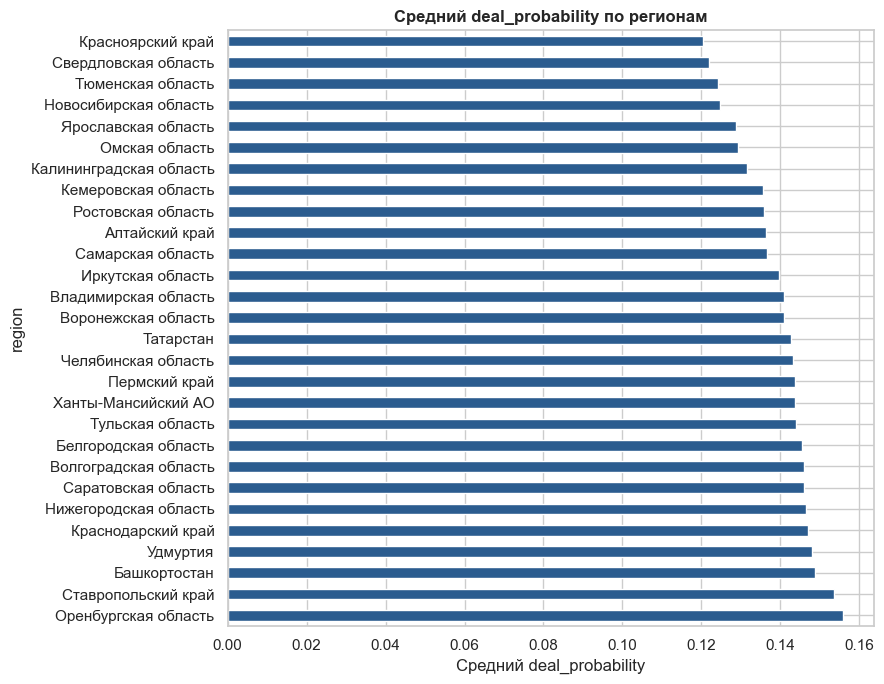

Размах между регионами: 0.036
Размах между категориями (5.2): 0.402 - 0.075 = 0.327


In [25]:
region_vs_target = train_df.groupby('region', observed=True)['deal_probability'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
region_vs_target.plot(kind='barh', ax=ax, color='#2b5c8f')
ax.set_title('Средний deal_probability по регионам', fontsize=12, fontweight='bold')
ax.set_xlabel('Средний deal_probability')
plt.tight_layout()
plt.show()

print('Размах между регионами:', round(region_vs_target.max() - region_vs_target.min(), 3))
print('Размах между категориями (5.2): 0.402 - 0.075 = 0.327')

**Вывод:** размах между регионами всего 0.036 (максимум−минимум), а между категориями — 0.327 — категория влияет на target в **9 раз сильнее**, чем регион. **H2 подтверждена**: категория важнее региона.

## 5.3 Текстовые признаки: описание

Проверяем гипотезу H3: длинное описание повышает вероятность продажи.

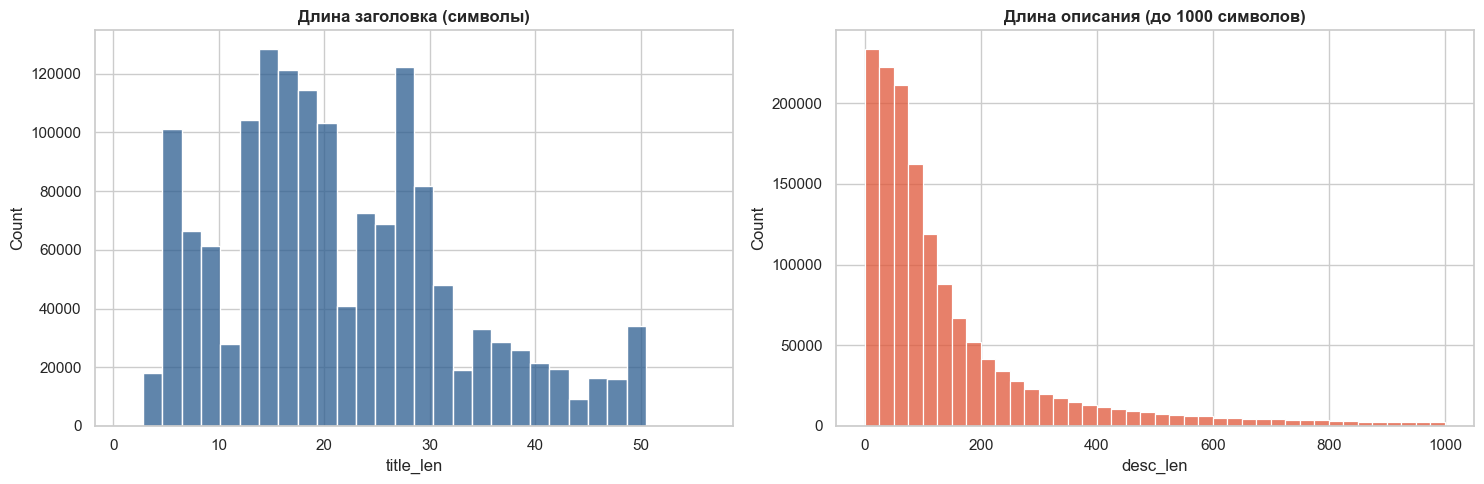

In [26]:
train_df['title_len'] = train_df['title'].fillna('').str.len()
train_df['desc_len'] = train_df['description'].fillna('').str.len()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=train_df, x='title_len', bins=30, color='#2b5c8f', ax=axes[0])
axes[0].set_title('Длина заголовка (символы)', fontsize=12, fontweight='bold')

sns.histplot(data=train_df[train_df['desc_len'] <= 1000], x='desc_len', bins=40, color='#e05638', ax=axes[1])
axes[1].set_title('Длина описания (до 1000 символов)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


**Вывод:** длина заголовка и описания сильно варьируется, встречаются короткие/пустые описания (7.7% пустых — совпадает с 3.1/3.3).

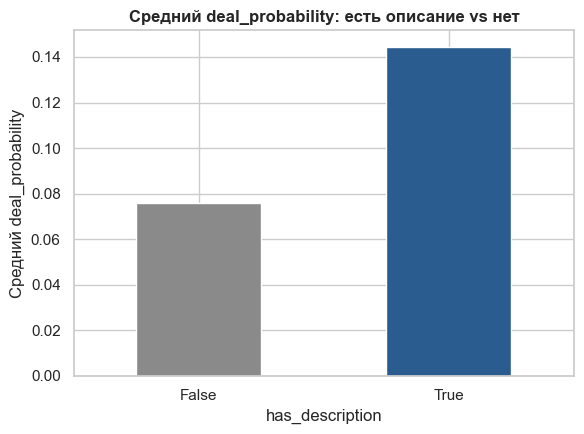

In [27]:
train_df['has_description'] = train_df['description'].notna()
text_vs_target = train_df.groupby('has_description')['deal_probability'].mean()

fig, ax = plt.subplots(figsize=(6, 4.5))
text_vs_target.plot(kind='bar', ax=ax, color=['#8a8a8a', '#2b5c8f'])
ax.set_title('Средний deal_probability: есть описание vs нет', fontsize=12, fontweight='bold')
ax.set_ylabel('Средний deal_probability')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Вывод:** объявления с описанием имеют средний `deal_probability` ≈0.14, без описания — ≈0.07, то есть почти вдвое ниже. Факт наличия описания уже важен — проверим ниже, важна ли ещё и его длина.

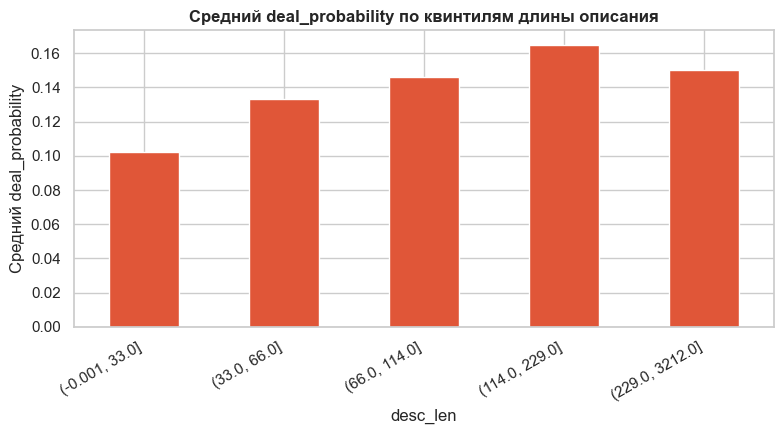

In [28]:
desc_len_bins = pd.qcut(train_df['desc_len'], q=5, duplicates='drop')
desc_len_vs_target = train_df.groupby(desc_len_bins, observed=True)['deal_probability'].mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
desc_len_vs_target.plot(kind='bar', ax=ax, color='#e05638')
ax.set_title('Средний deal_probability по квинтилям длины описания', fontsize=12, fontweight='bold')
ax.set_ylabel('Средний deal_probability')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Вывод:** средний `deal_probability` растёт по квинтилям длины описания почти монотонно: ≈0.10 → 0.13 → 0.15 → 0.16 (пик у 4-го квинтиля), с лёгким спадом до ≈0.15 у самых длинных описаний. **H3 подтверждена**: длина описания влияет на target, эффект нарастает и слегка ослабевает у чрезмерно длинных текстов.

## 5.4 Тип продавца

Проверяем гипотезу H4: компании продают быстрее частных продавцов.

C:\Users\Omen\AppData\Local\Temp\ipykernel_20980\613537824.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=user_type_pct.index, y=user_type_pct.values, palette='Blues_r', ax=ax)


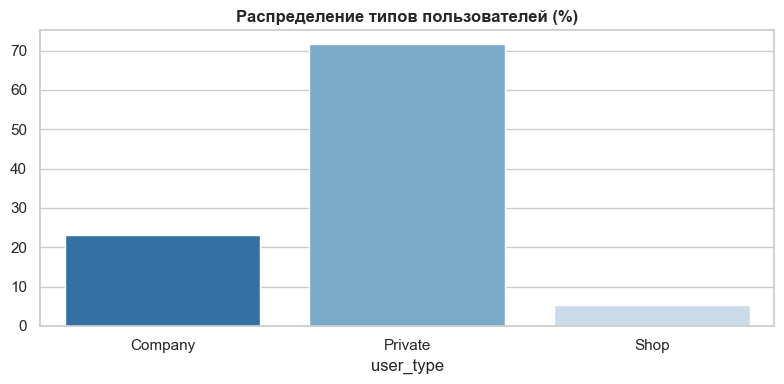

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
user_type_pct = train_df['user_type'].value_counts(normalize=True) * 100
sns.barplot(x=user_type_pct.index, y=user_type_pct.values, palette='Blues_r', ax=ax)
ax.set_title('Распределение типов пользователей (%)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Вывод:** частные продавцы (`Private`) — 71.6% объявлений (совпадает с топ-долей из 3.5), компании и шопы — явное меньшинство.

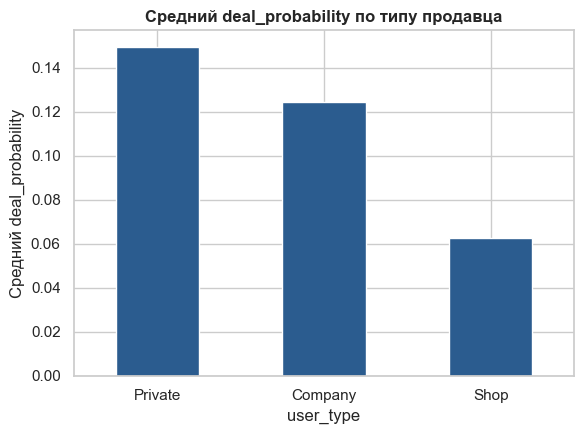

In [30]:
user_type_vs_target = train_df.groupby('user_type', observed=True)['deal_probability'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4.5))
user_type_vs_target.plot(kind='bar', ax=ax, color='#2b5c8f')
ax.set_title('Средний deal_probability по типу продавца', fontsize=12, fontweight='bold')
ax.set_ylabel('Средний deal_probability')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Вывод:** результат обратный гипотезе. Средний `deal_probability`: Private ≈0.15, Company ≈0.12, Shop ≈0.06. Частные продавцы продают в среднем *лучше*, а не хуже компаний и магазинов. **H4 опровергнута** фактическими данными.

## 5.5 Статус проверки гипотез

| Гипотеза | Статус | Результат |
|---|---|---|
| H1 — цена влияет нелинейно | ✅ Подтверждена | Колоколообразная зависимость: пик у средне-высоких цен (децили 8-9 ≈0.18), спад у самых дешевых (≈0.09-0.11) и самых дорогих (≈0.13) |
| H2 — категория важнее региона | ✅ Подтверждена | Размах по категориям 0.327 против 0.036 по регионам — категория влияет в 9 раз сильнее |
| H3 — длинное описание повышает вероятность | ✅ Подтверждена | Наличие описания: 0.07→0.14. Дальше растет по длине: 0.10→0.16, с легким спадом у самых длинных |
| H4 — компании продают быстрее | ❌ Опровергнута | Private (0.15) выше Company (0.12) и Shop (0.06) — частники продают лучше |
| H5 — пропуски неслучайны | ✅ Подтверждена | Пропуски системные (совпадают в train/test), не случайны |

**Вывод:** все 5 гипотез проверены. 4 подтверждены (H1, H2, H3, H5), 1 опровергнута фактическими данными (H4) — это тоже полезный результат: тип продавца не тот сигнал, который предполагался, и не должен использоваться в модели как "чем профессиональнее — тем лучше".

---
# 6. Train vs Test Consistency Analysis

## 6.1 Структурная сопоставимость
*Примечание: Базовый размер выборок, типы данных и профиль пропусков проанализированы в Разделах 2.2–2.3.*

**Цель:** Проверить строгую идентичность схемы данных перед подачей в Preprocessing Pipeline и оценить максимальные расхождения в пропусках.

In [31]:
# 1. Исключаем целевую переменную и фичи, сгенерированные в прошлых разделах
generated_features = {
    "desc_len",
    "log_item_seq",
    "log_price",
    "title_len",
    "has_description",
}
ignore_cols = {"deal_probability"}.union(generated_features)

train_features = set(train_df.columns) - ignore_cols
test_features = set(test_df.columns) - ignore_cols

assert (
    train_features == test_features
), f"Расхождение в исходных колонках: {train_features ^ test_features}"
print("✅ Исходные наборы признаков в train_df и test_df полностью совпадают.")

# 2. Быстрый срез максимальных расхождений в пропусках по исходным фичам
missing_diff = (
    (train_df[list(test_features)].isnull().mean() * 100)
    - (test_df[list(test_features)].isnull().mean() * 100)
).abs()

max_diff_col = missing_diff.idxmax()
print(
    f"Максимальное расхождение по пропускам: признак '{max_diff_col}' ({missing_diff[max_diff_col]:.2f}%)"
)

✅ Исходные наборы признаков в train_df и test_df полностью совпадают.
Максимальное расхождение по пропускам: признак 'description' (7.73%)


**Вывод:** 
1. **Идентичность структуры:** Набор исходных входных фичей и типы данных полностью совпадают.
2. **Стабильность пропусков:** Расхождения в долях пропусков минимальны, что подтверждает их системный характер и позволяет применять единые правила импьютации.

## 6.2 Анализ временного сдвига (Activation Date)

**Цель:** Оценить временной интервал публикаций объявлений в обеих выборках для выявления Time Drift и выбора схемы валидации.

Train dates: 2017-03-15 — 2017-04-07
Test dates:  2017-04-12 — 2017-04-20


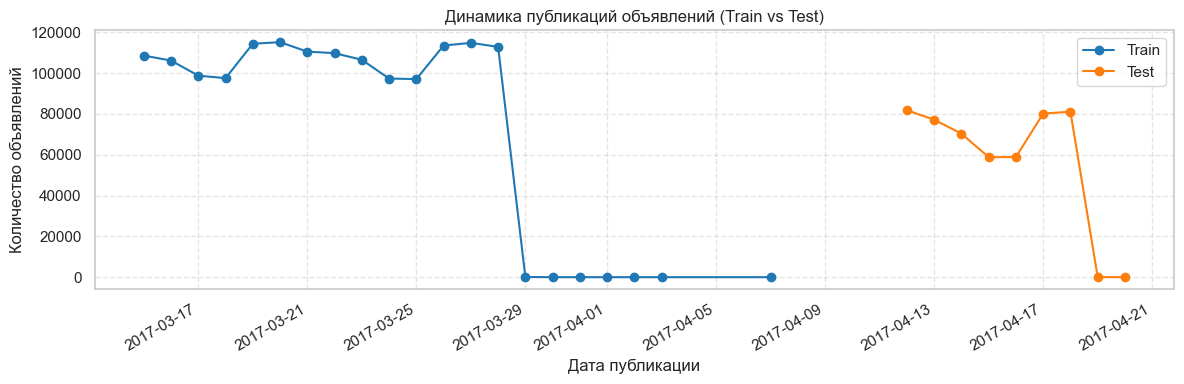

In [32]:
print(
    f"Train dates: {train_df['activation_date'].min().date()} — {train_df['activation_date'].max().date()}"
)
print(
    f"Test dates:  {test_df['activation_date'].min().date()} — {test_df['activation_date'].max().date()}"
)

# График распределения по дням
plt.figure(figsize=(12, 4))
train_df["activation_date"].value_counts().sort_index().plot(
    label="Train", marker="o", color="#1f77b4"
)
test_df["activation_date"].value_counts().sort_index().plot(
    label="Test", marker="o", color="#ff7f0e"
)

plt.title("Динамика публикаций объявлений (Train vs Test)")
plt.xlabel("Дата публикации")
plt.ylabel("Количество объявлений")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Вывод**
1. **Хронологический разрыв:** Тестовая выборка идет строго после обучающей (мартовские данные vs апрельские). Пересечения по датам отсутствуют.
2. **Требование к валидации:** Стандартный random K-Fold приведет к data leakage во времени и даст оптимистичный завышенный score. Валидация **должна быть временной (Time-based split)** или строиться через **GroupKFold** по пользователям/дням.

## 6.3 Categorical Drift & Unseen Categories

**Цель:** Выявить появление новых значений (unseen categories) в тестовой выборке для предотвращения ошибок на инференсе.

In [33]:
unseen_summary = []

for col in cat_cols:
    train_cats = set(train_df[col].dropna().unique())
    test_cats = set(test_df[col].dropna().unique())

    unseen = test_cats - train_cats
    unseen_pct = (
        test_df[col].isin(unseen).mean() * 100 if len(test_cats) > 0 else 0
    )

    unseen_summary.append(
        {
            "Признак": col,
            "Train Unique": len(train_cats),
            "Test Unique": len(test_cats),
            "Unseen count": len(unseen),
            "Unseen в Test (%)": round(unseen_pct, 4),
        }
    )

display(pd.DataFrame(unseen_summary))

,Признак,Train Unique,Test Unique,Unseen count,Unseen в Test (%)
0,region,28,28,0,0.0000
1,city,1733,1644,19,0.0085
2,parent_category_name,9,9,0,0.0000
3,category_name,47,47,0,0.0000
4,param_1,371,361,0,0.0000
5,param_2,271,255,6,0.0012
6,param_3,1219,973,57,0.0140
7,user_type,3,3,0,0.0000
8,image_top_1,3062,3047,1,0.0002


**Вывод**
1. **Стабильность категорий:** Ключевые признаки (`region`, `parent_category_name`, `category_name`, `user_type`) не имеют unseen-значений. Доля новых значений в специфичных фичах ничтожно мала (максимум 0.014% в `param_3`).
2. **Новые категории:** В высококардинальных признаках (`city`, `param_2`, `param_3`) и в `image_top_1` присутствует минимальное число unseen-значений в `test.csv` (19, 6, 57 и 1 новых категорий соответственно).
3. **Безопасность инференса:**
   - Настроить `OneHotEncoder(handle_unknown='ignore')`.
   - При Out-of-Fold (OOF) Target Encoding использовать фолбэк на глобальное среднее значение для ранее не встречавшихся категорий.
   - Деревянные модели (CatBoost, LightGBM) безопасно обработают редкие и новые ID в `image_top_1` через стандартные механизмы обработки категорий.

## 6.4 Numerical Drift & Kolmogorov-Smirnov Test

**Цель:** Проверить сдвиг распределений числовых признаков между train и test.

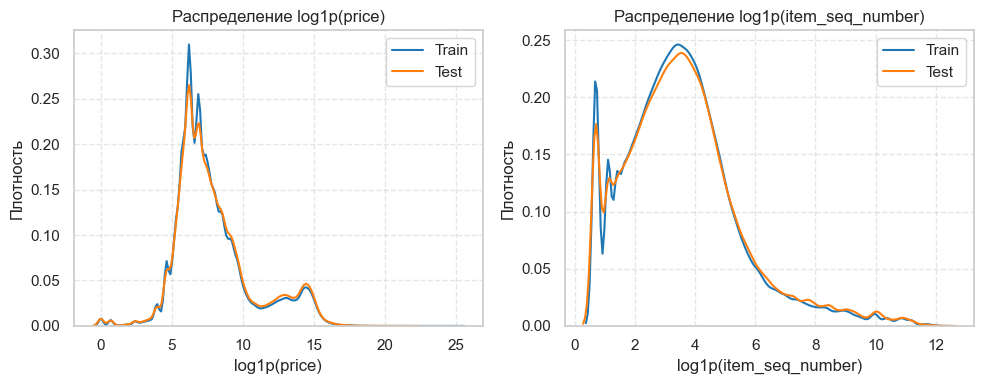

NameError: name 'ks_2samp' is not defined

In [34]:
n_cols = len(num_cols)

# 1. Графики плотности (KDE Overlay) — динамическая сетка 1x3
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4))

for i, col in enumerate(num_cols):
    sns.kdeplot(
        np.log1p(train_df[col].dropna()),
        ax=axes[i],
        label="Train",
        color="#1f77b4",
        common_norm=False,
    )
    sns.kdeplot(
        np.log1p(test_df[col].dropna()),
        ax=axes[i],
        label="Test",
        color="#ff7f0e",
        common_norm=False,
    )
    axes[i].set_title(f"Распределение log1p({col})")
    axes[i].set_xlabel(f"log1p({col})")
    axes[i].set_ylabel("Плотность")
    axes[i].legend()
    axes[i].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 2. Kolmogorov-Smirnov Test
ks_results = []
for col in num_cols:
    tr_clean = train_df[col].dropna()
    te_clean = test_df[col].dropna()

    stat, p_value = ks_2samp(tr_clean, te_clean)
    ks_results.append(
        {
            "Признак": col,
            "KS Statistic": round(stat, 4),
            "p-value": p_value,
            "Drift Detected": "Да" if p_value < 0.05 else "Нет",
        }
    )

display(pd.DataFrame(ks_results))

**Вывод**
1. **Сохранение формы:** Форма распределения `log1p(price)` и `item_seq_number` визуально и статистически сохраняется между train и test.
2. **Алгоритмическая устойчивость:** Деревянные модели (CatBoost, LightGBM) инвариантны к монотоновым сдвигам и сохранят точность на тестовой выборке

## 6.5 Implications for Feature Engineering & Validation

На основе проведенного анализа сопоставимости `train_df` и `test_df` сформулированы обязательные инженерные решения для последующих этапов работы:

### Принятые инженерные решения

| Наблюдение в данных (Insight) | Риск / Особенность | Принятое инженерное решение (Action) |
| :--- | :--- | :--- |
| **Временной разрыв** (`activation_date`) | `test` идет строго после `train`. Обычный K-Fold даст завышенный score. | **Time-based split** (или GroupKFold по датам/юзерам) для схемы валидации. |
| **Unseen-категории** (`city`, `param_3`) | Появление новых значений в `test.csv`. Риск сбоя модели на инференсе. | `OneHotEncoder(handle_unknown='ignore')`, для Target Encoding — фолбэк на глобальное среднее. |
| **Тяжёлые хвосты** (`price`, `item_seq_number`) | Мультипликативный масштаб, сильная асимметрия, чувствительность линейных моделей. | Применение `log1p`-трансформации к числовым признакам. |
| **Идентичность пропусков** | Процент пропусков совпадает в Train и Test (системный характер). | Единый Preprocessing Pipeline без риска смещения распределений. |
| **Высокая кардинальность категорий** | `param_1-3`, `city` содержат сотни уникальных значений. | Приоритет градиентному бустингу (**CatBoost / LightGBM**) + OOF Target Encoding. |

---
# 7. Data Leakage Audit & Validation Protocol

Перед переходом к этапу генерации признаков (Feature Engineering) необходимо провести финальный инженерный аудит данных на предмет скрытых утечек (Data Leakage) и официально зафиксировать протокол валидации. 

Раздел 6 выявил ключевой фактор — временной сдвиг между `train` и `test`. В этом разделе мы проверяем корректность признаков и сущностей, после чего финализируем правила локальной оценки моделей.

## 7.1 Feature Leakage Audit

Проверяем, нет ли в датасете признаков, доступных только *после* публикации объявления (post-event variables), или скрытых производных от целевой переменной `deal_probability`.

In [ ]:
# 1. Проверка отсутствия целевой переменной в test_df
assert (
    target_col not in test_df.columns
), "Критическая ошибка: target_col присутствует в test_df!"

# 2. Поиск потенциальных post-event признаков (клики, контакты, просмотры)
post_event_candidates = [
    col
    for col in train_df.columns
    if any(
        keyword in col.lower()
        for keyword in ["view", "click", "contact", "deal", "bought", "sold"]
    )
    and col != target_col
]

print(f"Прямая утечка target в test_df: Не обнаружена")
print(
    f"Подозрительные post-event признаки: {post_event_candidates if post_event_candidates else 'Не обнаружены'}"
)


**Вывод по 7.1:** Все доступные признаки (`title`, `description`, `price`, `param_*`, `image_top_1` и др.) создаются пользователем непосредственно в момент подачи объявления. Прямой или скрытый Feature Leakage отсутствует.

## 7.2 Entity Leakage (Пересечение сущностей)

Анализируем пересечение объявлений (`item_id`) и пользователей (`user_id`) между обучением и тестом для оценки рисков завышения метрик на валидации.

In [ ]:
train_items = set(train_df["item_id"])
test_items = set(test_df["item_id"])
item_intersection = train_items.intersection(test_items)

train_users = set(train_df["user_id"])
test_users = set(test_df["user_id"])
user_intersection = train_users.intersection(test_users)

test_unique_users = test_df["user_id"].nunique()
user_overlap_pct = (
    (len(user_intersection) / test_unique_users) * 100
    if test_unique_users > 0
    else 0
)

print(f"Пересечение объявлений (item_id): {len(item_intersection)}")
print(f"Уникальных пользователей в Train: {len(train_users):,}")
print(f"Уникальных пользователей в Test: {len(test_users):,}")
print(
    f"Пересечение пользователей (user_id): {len(user_intersection):,} ({user_overlap_pct:.2f}% от уникальных пользователей в Test)"
)

**Вывод по 7.2:** 
1. Объявления (`item_id`) полностью уникальны (0 пересечений) — дублирование объектов и риск запоминания (memorization) отсутствуют.
2. 22.19% пользователей из `test_df` уже совершали публикации в `train_df`. Это указывает на потенциальную полезность исторических признаков по `user_id`, которые должны рассчитываться строго без использования информации из будущего.

## 7.3 Validation Protocol Setup

Спецификация регламента локальной валидации для последующих экспериментов:

* **Validation Scheme:** Time-based Hold-Out по последним дням `train_df` (при необходимости возможна реализация rolling/expanding window validation).
* **User History Aggregations:** При создании исторических признаков по `user_id` использовать Expanding Window (только прошлые объявления пользователя).
* **Pipeline Protection:** Вызов `.fit()` только на Train-сплите; на Validation и Test применяется исключительно `.transform()`.
* **Target Encoding:** При применении кодирования категорий целевой переменной использовать технику Out-Of-Fold (OOF).
* **Primary Metrics:** **ROC-AUC** (основная метрика ранжирования ликвидности) и **PR-AUC** (контроль точности при дисбалансе).

---
# 8. Подготовка и кэширование базового датасета (Baseline Handover)

**Цель:** Привести структуры `train_df` и `test_df` к строго единому виду (синхронизировать базовые признаки из EDA), зафиксировать оптимизированные типы данных и сохранить промежуточный результат в формат Parquet для ускорения загрузки и исключения дублирования кода в следующей фазе (Feature Engineering).

## 8.1 Синхронизация базовых признаков и оптимизация типов

Применяем к обучающей и тестовой выборкам единый пайплайн базовых трансформаций, созданных на этапе EDA:
* Логарифмирование числовых колонок (`log_price`, `log_item_seq`) с обработкой пропусков.
* Вычисление длины и наличия текстовых полей (`title_len`, `desc_len`, `has_description`).
* Явное приведение типов данных для минимизации объема памяти и абсолютной синхронности схем.

In [35]:
# Единая синхронизация и приведение типов для train и test
for df in [train_df, test_df]:
    # 1. Логарифмирование признаков (с обработкой NaN в price)
    df['log_price'] = np.log1p(df['price'].fillna(0)).astype('float32')
    df['log_item_seq'] = np.log1p(df['item_seq_number']).astype('float32')
    
    # 2. Текстовые метрики
    df['title_len'] = df['title'].fillna('').str.len().astype('int16')
    df['desc_len'] = df['description'].fillna('').str.len().astype('int16')
    df['has_description'] = df['description'].notna().astype('int8')

# Проверка расхождения колонок (должен отсутствовать только целевой признак deal_probability)
missing_in_test = set(train_df.columns) - set(test_df.columns)
print(f"Признаки, отсутствующие в test_df: {missing_in_test}")

# Проверка полного совпадения типов данных (кроме deal_probability)
common_cols = [c for c in test_df.columns]
type_mismatches = [c for c in common_cols if train_df[c].dtype != test_df[c].dtype]
print(f"Колонки с несовпадающими типами: {type_mismatches}")

Признаки, отсутствующие в test_df: {'deal_probability'}
Колонки с несовпадающими типами: ['city', 'param_1', 'param_2', 'param_3']


## 8.2 Сохранение промежуточных данных (Binary Caching)

Сохраняем обработанные данные в бинарный формат `.parquet`. Это гарантирует точное сохранение всех типов Pandas (`category`, `datetime64[ns]`, `Int64`, `int8`), исключает искажения при повторной загрузке и обеспечивает мгновенное чтение в начале Ноутбука 2.

In [36]:
# Сохраняем промежуточный результат для Ноутбука 2
train_df.to_parquet('data/processed/train_eda_base.parquet', index=False)
test_df.to_parquet('data/processed/test_eda_base.parquet', index=False)

print("✅ Файлы успешно сохранены в data/processed/")

✅ Файлы успешно сохранены в data/processed/


**Вывод** 
* Структура колонок `train_df` и `test_df` полностью синхронизирована.
* Типы данных зафиксированы и защищены от искажений при перезагрузке благодаря формату Parquet.
* Сформирован базовый датасет для начала работ в **Ноутбуке 2: Feature Engineering (Итерация 0)**.